In [12]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))
from src.nlp_pipeline import lemmatization
from src.data_cleaning import clean_nonprofit_data
from gensim.corpora import Dictionary
from gensim.models import LdaModel, CoherenceModel

Computing Coherence Scores for Each Topic

In [13]:

def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):
    coherence_values = []
    model_list = []
    
    for num_topics in range(start, limit, step):
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            chunksize=1000,
            passes=10
        )
        model_list.append(model)
        
        # C_v coherence measures the semantic similarity of the top words
        coherencemodel = CoherenceModel(
            model=model, 
            texts=texts, 
            dictionary=dictionary, 
            coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())
        print(f"Completed model for T={num_topics}")

    return model_list, coherence_values

In [14]:
nonprofits = clean_nonprofit_data('../data/all_va.parquet')

# Preprocessing
lemmatized_texts = lemmatization(nonprofits["IRS990_ActivityOrMissionDesc"].dropna())
tokenized_texts = [text.split() for text in lemmatized_texts]

# Generate Dictionary and Bag-of-Words Corpus
dictionary = Dictionary(tokenized_texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in tokenized_texts]

Determining the Optimal Number of Topics

Completed model for T=2
Completed model for T=8
Completed model for T=14
Completed model for T=20
Completed model for T=26
Completed model for T=32
Completed model for T=38


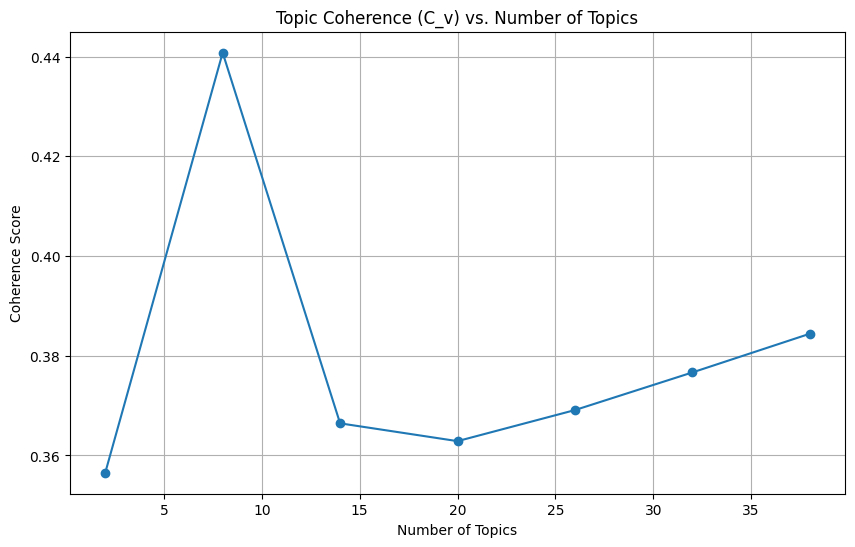

In [15]:
# Range settings used for the CNE 2026 report analysis
START, LIMIT, STEP = 2, 40, 6

model_list, coherence_values = compute_coherence_values(
    dictionary=dictionary, 
    corpus=corpus, 
    texts=tokenized_texts, 
    start=START, limit=LIMIT, step=STEP
)

# Plotting the results to find the 'Elbow'
x = range(START, LIMIT, STEP)
plt.figure(figsize=(10, 6))
plt.plot(x, coherence_values, marker='o')
plt.title("Topic Coherence (C_v) vs. Number of Topics")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.grid(True)
plt.show()